# Listing Remarks Exploration

This notebook explores patterns in the real estate listing remarks, including text length, common terms, and n-grams.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Ensure project root is on sys.path so `scripts` can be imported
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline

remarks_df = pd.read_csv("../data/processed/listing_sample.csv")
remarks_df["length"] = remarks_df["remarks"].astype(str).str.len()

remarks_df[["length"]].describe()

,length
count,1000.000000
mean,1197.498000
std,541.749997
min,67.000000
25%,825.500000
50%,1143.000000
75%,1465.000000
max,3678.000000


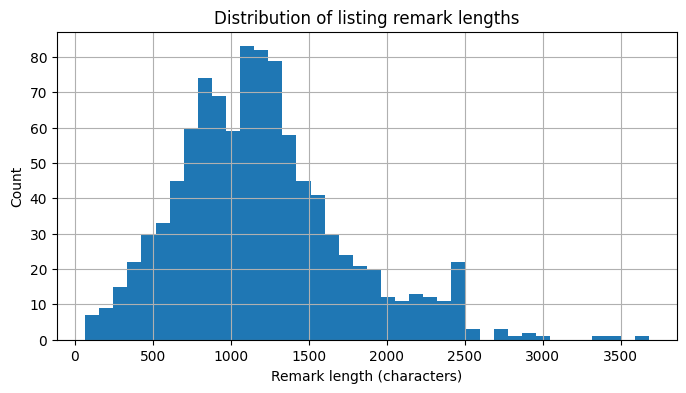

In [2]:
# Histogram of remark lengths
plt.figure(figsize=(8, 4))
remarks_df["length"].hist(bins=40)
plt.xlabel("Remark length (characters)")
plt.ylabel("Count")
plt.title("Distribution of listing remark lengths")
plt.show()

In [3]:
# Simple token frequency exploration
all_text = " ".join(remarks_df["remarks"].astype(str).str.lower())
words = all_text.split()
word_counts = Counter(words)

for word, count in list(word_counts.most_common(30)):
    print(f"{word}: {count}")

and: 8690
the: 7439
a: 7352
with: 3593
to: 3058
of: 2603
for: 2488
this: 2290
in: 2184
home: 1869
is: 1724
an: 1319
living: 1244
or: 1113
offers: 868
room: 824
kitchen: 755
private: 731
on: 673
features: 666
that: 636
from: 616
spacious: 605
located: 601
your: 599
perfect: 582
new: 581
large: 515
space: 491
by: 475


In [4]:
from scripts.text_cleaning import TextCleaner

cleaner = TextCleaner()

before_profile = cleaner.profile_column(remarks_df, "remarks")
remarks_df["remarks_clean"] = remarks_df["remarks"].apply(cleaner.clean_text)
after_profile = cleaner.profile_column(remarks_df, "remarks_clean")

before_profile, after_profile

({'null_rate': 0.0,
  'avg_length': 1197.498,
  'common_terms': [('and a', 1067),
   ('in the', 744),
   ('with a', 676),
   ('of the', 574),
   ('to the', 568),
   ('this home', 469),
   ('perfect for', 466),
   ('the home', 441),
   ('square feet', 405),
   ('walk in', 404),
   ('is a', 384),
   ('ideal for', 350),
   ('a private', 337),
   ('access to', 311),
   ('primary suite', 303),
   ('living room', 293),
   ('to a', 276),
   ('welcome to', 276),
   ('car garage', 267),
   ('and the', 266)],
  'price_mentions': 65,
  'has_html': 0,
  'common_abbreviations': [('ac', 980),
   ('ba', 923),
   ('dr', 906),
   ('ss', 867),
   ('fr', 787),
   ('kit', 754),
   ('br', 552),
   ('gar', 537),
   ('att', 212),
   ('gran', 197),
   ('det', 156),
   ('hoa', 128),
   ('hw', 112),
   ('sq ft', 96),
   ('hvac', 70),
   ('sf', 60),
   ('sqft', 34),
   ('w/', 28),
   ('a/c', 27),
   ('lr', 25)]},
 {'null_rate': 0.0,
  'avg_length': 1203.117,
  'common_terms': [('and a', 1067),
   ('in the', 744)

In [6]:
# Before/after examples
remarks_df[["remarks", "remarks_clean"]].head(10)
remarks_df[["remarks", "remarks_clean"]].tail(10)

,remarks,remarks_clean
990,Discover this beautifully maintained residence...,Discover this beautifully maintained residence...
991,"A smart alternative to traditional housing, th...","A smart alternative to traditional housing, th..."
992,"Stunning Bay, City, and Sunset Views!!!!! Fro...","Stunning Bay, City, and Sunset Views! From Thi..."
993,"Welcome to this beautifully updated 4-bedroom,...","Welcome to this beautifully updated 4-bedroom,..."
994,Experience luxury high-rise living at its fine...,Experience luxury high-rise living at its fine...
995,"Nice 3 bedroom, 2 bath 1100 Sq ft home with fi...","Nice 3 bedroom, 2 bath 1100 square feet home w..."
996,Located in the highly coveted Lake Hollywood E...,Located in the highly coveted Lake Hollywood E...
997,Discover your dream mountain retreat at 7575 U...,Discover your dream mountain retreat at 7575 U...
998,NEW LOWER PRICE! Check out this beautiful sing...,NEW LOWER PRICE! Check out this beautiful sing...
999,Welcome to your dream home in Palm Desert! Thi...,Welcome to your dream home in Palm Desert! Thi...
